In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")
tags = pd.read_csv("tags.csv")
links = pd.read_csv("links.csv")
genome_scores = pd.read_csv("genome-scores.csv")
genome_tags = pd.read_csv("genome-tags.csv")
movies.head(), ratings.head(), tags.head(), links.head()

(   movieId                               title  \
 0        1                    Toy Story (1995)   
 1        2                      Jumanji (1995)   
 2        3             Grumpier Old Men (1995)   
 3        4            Waiting to Exhale (1995)   
 4        5  Father of the Bride Part II (1995)   
 
                                         genres  
 0  Adventure|Animation|Children|Comedy|Fantasy  
 1                   Adventure|Children|Fantasy  
 2                               Comedy|Romance  
 3                         Comedy|Drama|Romance  
 4                                       Comedy  ,
    userId  movieId  rating   timestamp
 0       1      296     5.0  1147880044
 1       1      306     3.5  1147868817
 2       1      307     5.0  1147868828
 3       1      665     5.0  1147878820
 4       1      899     3.5  1147868510,
    userId  movieId               tag   timestamp
 0       3      260           classic  1439472355
 1       3      260            sci-fi  1439472256


In [2]:
# Remove duplicates
movies.drop_duplicates(inplace=True)
ratings.drop_duplicates(inplace=True)
tags.drop_duplicates(inplace=True)

# Clean genres & tags
movies["genres"] = movies["genres"].replace("(no genres listed)", "Unknown").str.strip()
tags["tag"] = tags["tag"].fillna("").str.strip().str.lower()

# Keep only valid rating range
ratings = ratings[(ratings["rating"] >= 0.5) & (ratings["rating"] <= 5)]

# Remove invalid movieIds
valid_ids = set(movies["movieId"])
ratings = ratings[ratings["movieId"].isin(valid_ids)]
tags = tags[tags["movieId"].isin(valid_ids)]

# Replace missing IDs in links
links = links.fillna(0)


(62423, 3) (25000095, 4) (1093360, 4)
movieId    0
title      0
genres     0
dtype: int64
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64


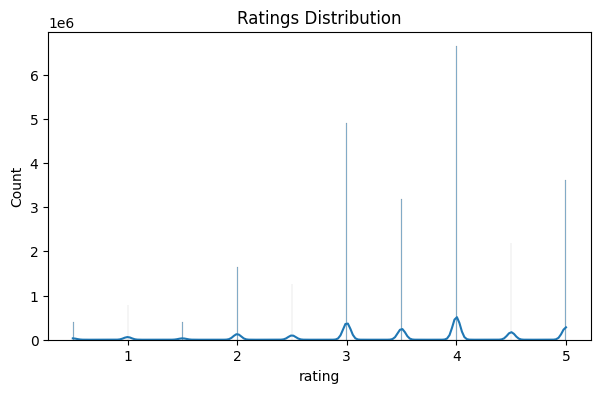

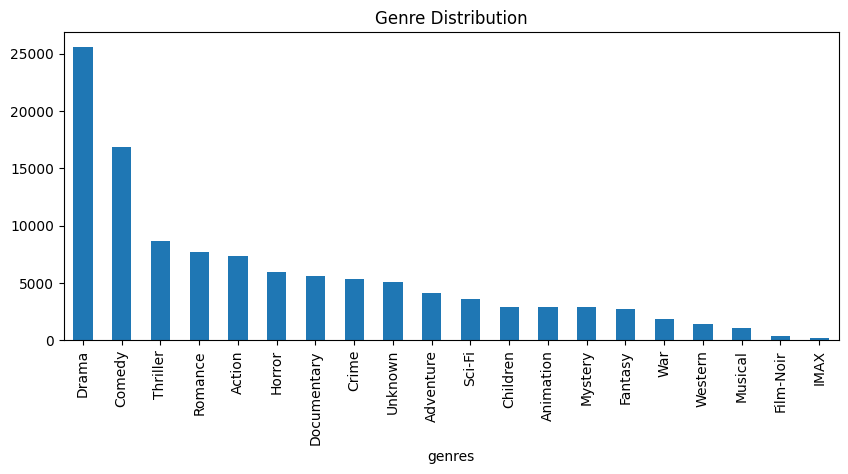

In [3]:
print(movies.shape, ratings.shape, tags.shape)
print(movies.isnull().sum())
print(ratings.isnull().sum())
print(tags.isnull().sum())

plt.figure(figsize=(7,4))
sns.histplot(ratings["rating"], kde=True)
plt.title("Ratings Distribution")
plt.show()

genre_list = movies["genres"].str.split("|").explode()
genre_list.value_counts().plot(kind="bar", figsize=(10,4))
plt.title("Genre Distribution")
plt.show()


In [4]:
movies["genres"] = movies["genres"].str.replace("|", " ")

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movies["genres"].str.split())

genre_df = pd.DataFrame(genre_matrix, columns=mlb.classes_)
genre_df.index = movies.index


In [5]:
rating_stats = ratings.groupby("movieId").agg(
    mean_rating=("rating", "mean"),
    rating_count=("rating", "count")
)

movie_features = movies.merge(rating_stats, on="movieId", how="left")
movie_features[["mean_rating", "rating_count"]] = movie_features[["mean_rating", "rating_count"]].fillna(0)


In [6]:
# Combine all tags into a text string per movie
movie_tag_text = tags.groupby("movieId")["tag"].apply(lambda x: " ".join(x)).reset_index()

# TF-IDF with controlled dimensionality
tfidf = TfidfVectorizer(max_features=1000)
tag_tfidf = tfidf.fit_transform(movie_tag_text["tag"])

# Convert to DataFrame
tag_tfidf_df = pd.DataFrame(tag_tfidf.toarray(), columns=tfidf.get_feature_names_out())
tag_tfidf_df["movieId"] = movie_tag_text["movieId"]

# Merge into main table
movie_features = movie_features.merge(tag_tfidf_df, on="movieId", how="left").fillna(0)


In [16]:
genome_full = genome_scores.merge(genome_tags, on="tagId")

genome_matrix = genome_full.pivot_table(
    index="movieId",
    columns="tag",
    values="relevance",
    fill_value=0
)

movie_features = movie_features.merge(genome_matrix, on="movieId", how="left").fillna(0)


In [8]:
movie_features = movie_features.merge(links, on="movieId", how="left")


In [17]:
# ------------------------------------
# STEP 9 — FIXED FEATURE SELECTION
# ------------------------------------

# 1. REMOVE GENRE COLUMNS IF THEY ALREADY EXIST BEFORE JOINING
genre_columns = genre_df.columns.tolist()

# Check if the columns already exist
existing_genres = [col for col in genre_columns if col in movie_features.columns]

# If genre columns DO NOT exist, join them
if len(existing_genres) == 0:
    movie_features = movie_features.join(genre_df, how="left")
else:
    print("Genre columns already exist — skipping genre join.")

# 2. COLUMNS TO DROP (Corrected for your dataset with title_x)
cols_to_drop = ["movieId", "title_x", "genres", "imdbId", "tmdbId"]

# Drop only columns that exist to avoid KeyError
cols_to_drop = [col for col in cols_to_drop if col in movie_features.columns]

# 3. SELECT ONLY NUMERIC FEATURES
X = movie_features.drop(columns=cols_to_drop)

# 4. REMOVE ZERO-VARIANCE FEATURES
selector = VarianceThreshold(threshold=0.0)
X_reduced = selector.fit_transform(X)

X = pd.DataFrame(X_reduced, columns=X.columns[selector.get_support()])

print("Final feature matrix shape:", X.shape)


Genre columns already exist — skipping genre join.
Final feature matrix shape: (62423, 3278)


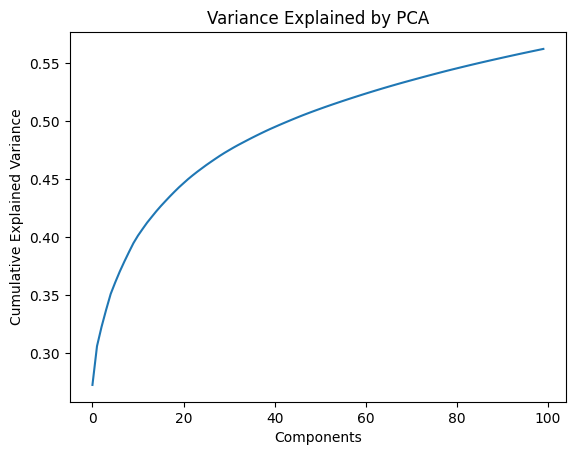

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=100, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title("Variance Explained by PCA")
plt.xlabel("Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()


In [19]:
kmeans = KMeans(n_clusters=30, random_state=42, n_init=10)
movie_features["cluster"] = kmeans.fit_predict(X_pca)

movie_features["cluster"].value_counts()


cluster
0     48610
3      1752
26     1609
5       885
7       731
11      683
1       653
14      602
29      590
6       492
2       488
19      471
18      467
15      410
27      403
8       369
13      355
16      317
25      302
12      301
17      293
22      293
4       271
20      239
28      191
24      172
21      163
23      148
9       137
10       26
Name: count, dtype: int64

In [20]:
def recommend_similar_movies(movie_title, n=10):
    row = movie_features[movie_features["title_x"].str.contains(movie_title, case=False, regex=False)]
    if row.empty:
        return "Movie not found."

    cluster_id = row.iloc[0]["cluster"]
    cluster_movies = movie_features[movie_features["cluster"] == cluster_id]

    cluster_movies = cluster_movies[cluster_movies["title_x"] != row.iloc[0]["title_x"]]

    cluster_movies = cluster_movies.sort_values(
        by=["mean_rating", "rating_count"],
        ascending=False
    )

    return cluster_movies.head(n)[[
        "movieId", "title_x", "mean_rating", "rating_count", "cluster", "imdbId", "tmdbId"
    ]]


In [21]:
# 1. Silhouette Score
print("Silhouette Score:", silhouette_score(X_pca, movie_features["cluster"]))

# 2. Calinski-Harabasz Index
print("Calinski-Harabasz Score:", calinski_harabasz_score(X_pca, movie_features["cluster"]))

# 3. Davies-Bouldin Index
print("Davies-Bouldin Score:", davies_bouldin_score(X_pca, movie_features["cluster"]))

# 4. Cluster Coherence (lower = better)
def cluster_coherence(df):
    return df.groupby("cluster")["mean_rating"].std().mean()

print("Cluster Coherence:", cluster_coherence(movie_features))

# 5. Genre Similarity (recommendation evaluation)
def genre_similarity(movie_title):
    row = movies[movies["title"].str.contains(movie_title, case=False, regex=False)]
    if row.empty:
        return None
    base_genres = set(row.iloc[0]["genres"].split("|"))
    
    recs = recommend_similar_movies(movie_title, 10)
    overlaps = []
    for _, r in recs.iterrows():
        rec_genres = set(movies[movies["movieId"] == r["movieId"]]["genres"].iloc[0].split("|"))
        overlaps.append(len(base_genres.intersection(rec_genres)))
    return np.mean(overlaps)

print("Genre Similarity (Toy Story):", genre_similarity("Toy Story"))


Silhouette Score: 0.7343389625200639
Calinski-Harabasz Score: 4130.200390035388
Davies-Bouldin Score: 2.2543518198076455
Cluster Coherence: 0.36642116020513454
Genre Similarity (Toy Story): 2.5


In [22]:
import pickle

pickle.dump(movie_features, open("movie_features.pkl", "wb"))
pickle.dump(kmeans, open("kmeans_model.pkl", "wb"))
pickle.dump(pca, open("pca_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
